In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.lines import Line2D


sns.set_context("talk")


In [3]:
def read_temperature(results_directory):
    df_list=list()
    for dirname in os.listdir(results_directory):
        if not "prod" in dirname and not "nvt" in dirname and not "npt" in dirname:
            continue
        data_directory=os.path.join(results_directory,dirname)
        for filename in os.listdir(data_directory):
            if not "temperature" in filename or not "csv" in filename:
                continue
            file_path=os.path.join(data_directory,filename)
            df_tmp=pd.read_csv(file_path,names=['Time (ps)',"Temperature (K)"],skiprows=1)
            target_temperature=int(os.path.split(data_directory)[-1].split("_")[-1])
            df_tmp["Target Temperature (K)"]=target_temperature
            phase=os.path.split(data_directory)[-1].split("_")[-2]
            df_tmp["Ensemble"]=phase
            if phase=="nvt":
                df_tmp['Time (ps)']+=50
            df_list.append(df_tmp)
    df=pd.concat(df_list,ignore_index=True)
    df['Time (ns)']=df['Time (ps)']*0.001

    return df
df_temperature=read_temperature("../result/gromacs/pore/4nm/protocol/result/high_to_low/")
df_temperature

,Time (ps),Temperature (K),Target Temperature (K),Ensemble,Time (ns)
0,0.0,101.058319,100,prod,0.000
1,2.0,100.181198,100,prod,0.002
2,4.0,101.859673,100,prod,0.004
3,6.0,100.143211,100,prod,0.006
4,8.0,98.687202,100,prod,0.008
...,...,...,...,...,...
523,56.0,50.246368,50,nvt,0.056
524,57.0,49.812290,50,nvt,0.057
525,58.0,50.177345,50,nvt,0.058
526,59.0,48.827393,50,nvt,0.059


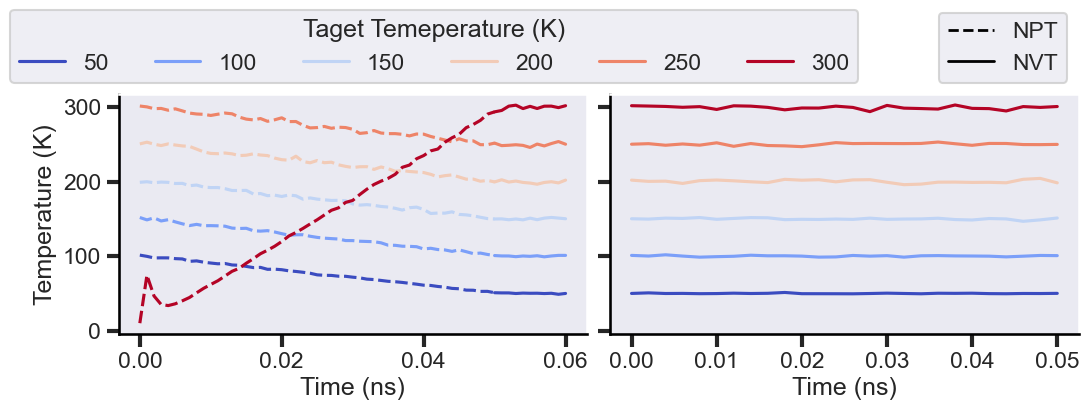

In [4]:
fig, axs = plt.subplots(ncols=2,figsize=(6*2,3),sharey=True)
sns.set_context("talk")

ax=axs[0]
sns.lineplot(data=df_temperature.query("Ensemble != 'prod'")
    , y='Temperature (K)'
    , x='Time (ns)'
    ,hue="Target Temperature (K)"
    ,palette="coolwarm"
    ,style="Ensemble"
    ,style_order=["nvt","npt"]
    ,legend=False
    ,ax=ax
            )

custom_lines = [Line2D([0], [0], color="black", lw=2,linestyle="dashed")
                ,Line2D([0], [0], color="black", lw=2)]
ax.legend(custom_lines,["NPT","NVT"])
sns.move_legend(ax,'lower right'
                ,bbox_to_anchor=(0.9,0.9)
                ,ncol=1
                ,bbox_transform=fig.transFigure)

ax=axs[1]
sns.lineplot(data=df_temperature.query("Ensemble == 'prod'")
    , y='Temperature (K)'
    , x='Time (ns)'
    ,hue="Target Temperature (K)"
    ,palette="coolwarm"
    #,style="Target Temperature (K)"
    ,ax=ax
    ,legend=True
            )
sns.move_legend(ax,'lower left'
                ,bbox_to_anchor=(0,0.9)
                ,ncol=6
                ,bbox_transform=fig.transFigure
                ,title="Taget Temeperature (K)")



for ax in axs:
    ax.spines['bottom'].set_color('0')
    ax.spines['top'].set_color('1')
    ax.spines['right'].set_color('1')
    ax.spines['left'].set_color('0')
    ax.tick_params(direction='out', width=3, bottom=True, left=True)
    ax.grid(False)


plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.05, 
                    hspace=0)

plt.savefig("../figures/fig2.pdf", pad_inches=0.2,bbox_inches="tight")